In [1]:
%pip install aiohttp

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Ana Khan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import time
import aiohttp
import urllib.parse
from IPython.display import Image, display

In [3]:
subscriptionKey = "5LntZI4pdj9NYxl4747ESUnG0NzjcmAj9R9DaKnSUT13wKGZPxNoJQQJ99CFACYeBjF4YdtHAAAgAZMP3qI5"
currentLocation = [24.7236, 46.6208]     # KSU
destination = [24.9576, 46.6988]          # Riyadh Airport
session = aiohttp.ClientSession()

# Parameters for the vehicle consumption model
travelMode = "car"
vehicleEngineType = "electric"
currentChargeInkWh = 60
maxChargeInkWh = 80
timeBudgetInSec = 1000
routeType = "eco"
constantSpeedConsumptionInkWhPerHundredkm = "50,8.2:130,21.3"

# Get boundaries for the electric vehicle's reachable range.
routeRangeResponse = await (await session.get("https://atlas.microsoft.com/route/range/json?subscription-key={}&api-version=1.0&query={}&travelMode={}&vehicleEngineType={}&currentChargeInkWh={}&maxChargeInkWh={}&timeBudgetInSec={}&routeType={}&constantSpeedConsumptionInkWhPerHundredkm={}"
                                              .format(subscriptionKey, str(currentLocation[0])+","+str(currentLocation[1]), travelMode, vehicleEngineType, currentChargeInkWh, maxChargeInkWh, timeBudgetInSec, routeType, constantSpeedConsumptionInkWhPerHundredkm))).json()

polyBounds = routeRangeResponse["reachableRange"]["boundary"]

for i in range(len(polyBounds)):
    coordList = list(polyBounds[i].values())
    coordList[0], coordList[1] = coordList[1], coordList[0]
    polyBounds[i] = coordList

polyBounds.pop()
polyBounds.append(polyBounds[0])

boundsData = {
    "geometry": {
        "type": "Polygon",
        "coordinates":
        [
            polyBounds
        ]
    }
}

In [4]:
print("polyBounds sample:", polyBounds[:3])
print("number of boundary points:", len(polyBounds))

polyBounds sample: [[46.62083, 24.74972], [46.60153, 24.82121], [46.59706, 24.81933]]
number of boundary points: 50


In [5]:
# Search for electric vehicle stations within reachable range.
searchPolyResponse = await (await session.post(url="https://atlas.microsoft.com/search/geometry/json?subscription-key={}&api-version=1.0&query=electric vehicle charging station&idxSet=POI&limit=50".format(subscriptionKey), json=boundsData)).json()

reachableLocations = []
for loc in range(len(searchPolyResponse["results"])):
    location = list(searchPolyResponse["results"][loc]["position"].values())
    location[0], location[1] = location[1], location[0]
    reachableLocations.append(location)

In [6]:
print("number of reachableLocations:", len(reachableLocations))
print("sample locations:", reachableLocations[:3])

number of reachableLocations: 27
sample locations: [[46.586281, 24.688565], [46.627996, 24.690455], [46.626532, 24.665424]]


Range map status: 200


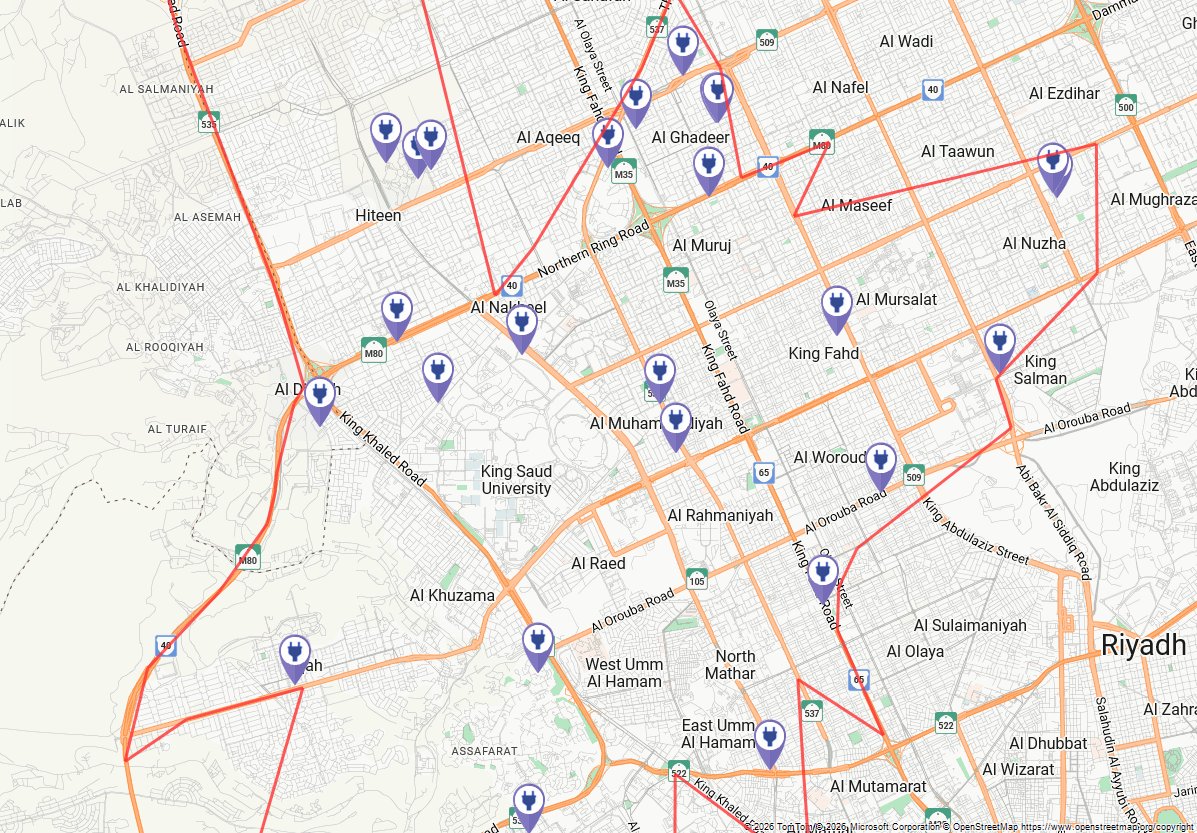

In [ ]:
# Get boundaries for the bounding box.
def getBounds(polyBounds):
    maxLon = max(map(lambda x: x[0], polyBounds))
    minLon = min(map(lambda x: x[0], polyBounds))
    maxLat = max(map(lambda x: x[1], polyBounds))
    minLat = min(map(lambda x: x[1], polyBounds))
    lonBuffer = (maxLon - minLon) * 0.1
    minLon -= lonBuffer
    maxLon += lonBuffer
    latBuffer = (maxLat - minLat) * 0.1
    minLat -= latBuffer
    maxLat += latBuffer
    # Clamp to Azure zoom-12 limits (max 0.34 x 0.13, min 0.02 x 0.01)
    cLon = (minLon + maxLon) / 2
    cLat = (minLat + maxLat) / 2
    w = min(max(maxLon - minLon, 0.02), 0.34)
    h = min(max(maxLat - minLat, 0.01), 0.13)
    minLon, maxLon = cLon - w/2, cLon + w/2
    minLat, maxLat = cLat - h/2, cLat + h/2
    return [minLon, maxLon, minLat, maxLat]


minLon, maxLon, minLat, maxLat = getBounds(polyBounds)
polyBoundsFormatted = '|'.join('{} {}'.format(c[0], c[1]) for c in polyBounds)
reachableLocationsFormatted = '|'.join(
    '{} {}'.format(c[0], c[1]) for c in reachableLocations)

path = "lcff3333|lw3|la0.80|fa0.35||{}".format(polyBoundsFormatted)
pins = "custom|an15 53||{}||https://raw.githubusercontent.com/Azure-Samples/AzureMapsCodeSamples/e3a684e7423075129a0857c63011e7cfdda213b7/Static/images/icons/ev_pin.png".format(
    reachableLocationsFormatted)

encodedPath = urllib.parse.quote(path, safe='')   # FIX: encode path
encodedPins = urllib.parse.quote(pins, safe='')   # FIX: encode pins
bbox = "{},{},{},{}".format(minLon, minLat, maxLon, maxLat)

staticMapResponse = await session.get(
    "https://atlas.microsoft.com/map/static?api-version=2024-04-01&subscription-key={}&pins={}&path={}&bbox={}".format(
        subscriptionKey, encodedPins, encodedPath, bbox))

print("Range map status:", staticMapResponse.status)
poiRangeMap = await staticMapResponse.content.read()
if staticMapResponse.status == 200:
    display(Image(poiRangeMap))
else:
    print("Error:", poiRangeMap.decode(errors='replace'))

In [8]:
print(searchPolyResponse.keys())
print(searchPolyResponse["results"])

dict_keys(['summary', 'results'])
[{'type': 'POI', 'id': 'QEjLJEhs7HlIk47p5599AQ', 'score': 9.4402446747, 'info': 'search:ev:3cb14d3f-df00-882a-9e6a-4e8e07e5256c', 'poi': {'name': 'E-Fill', 'phone': '+966 12 236 4777', 'brands': [{'name': 'E-Fill'}], 'categorySet': [{'id': 7309}], 'url': 'https://alsharifx.com/home.php', 'categories': ['electric vehicle station'], 'classifications': [{'code': 'ELECTRIC_VEHICLE_STATION', 'names': [{'nameLocale': 'en-US', 'name': 'electric vehicle station'}]}]}, 'address': {'streetNumber': '3004', 'streetName': 'شارع بني شقير', 'municipalitySubdivision': 'Irqah', 'municipality': 'Riyadh', 'countrySubdivision': 'Riyadh Province', 'countrySubdivisionName': 'Riyadh Province', 'countrySubdivisionCode': '1', 'postalCode': '12586', 'countryCode': 'SA', 'country': 'Saudi Arabia', 'countryCodeISO3': 'SAU', 'freeformAddress': '3004 شارع بني شقير, Irqah, الرياض 12586', 'localName': 'الرياض'}, 'position': {'lat': 24.688565, 'lon': 46.586281}, 'viewport': {'topLeftP

In [9]:
locationData = {
    "origins": {
        "type": "MultiPoint",
        "coordinates": [[currentLocation[1], currentLocation[0]]]
    },
    "destinations": {
        "type": "MultiPoint",
        "coordinates": reachableLocations
    }
}

# Get the travel time and distance to each specified charging station.
searchPolyRes = await (await session.post(url="https://atlas.microsoft.com/route/matrix/json?subscription-key={}&api-version=1.0&routeType=shortest&waitForResults=true".format(subscriptionKey), json=locationData)).json()

distances = []
for dist in range(len(reachableLocations)):
    distances.append(searchPolyRes["matrix"][0][dist]
                     ["response"]["routeSummary"]["travelTimeInSeconds"])

minDistLoc = []
minDistIndex = distances.index(min(distances))
minDistLoc.extend([reachableLocations[minDistIndex][1],
                  reachableLocations[minDistIndex][0]])
closestChargeLoc = ",".join(str(i) for i in minDistLoc)

In [10]:
# Get the route from the electric vehicle's current location to the closest charging station.
routeResponse = await (await session.get("https://atlas.microsoft.com/route/directions/json?subscription-key={}&api-version=1.0&query={}:{}".format(subscriptionKey, str(currentLocation[0])+","+str(currentLocation[1]), closestChargeLoc))).json()

route = []
for loc in range(len(routeResponse["routes"][0]["legs"][0]["points"])):
    location = list(routeResponse["routes"][0]
                    ["legs"][0]["points"][loc].values())
    location[0], location[1] = location[1], location[0]
    route.append(location)

routeData = {
    "type": "LineString",
    "coordinates": route
}

Route map status: 200


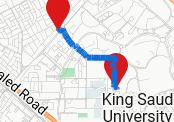

In [ ]:
destination = route[-1]

routeFormatted = '|'.join('{} {}'.format(c[0], c[1]) for c in route)
path = "lc0f6dd9|lw6||{}".format(routeFormatted)
pins = "default|codb1818||{} {}|{} {}".format(
    currentLocation[1], currentLocation[0],
    destination[0], destination[1])

encodedPath = urllib.parse.quote(path, safe='')   # FIX: encode path
encodedPins = urllib.parse.quote(pins, safe='')   # FIX: encode pins

minLon, maxLon = sorted([float(destination[0]), currentLocation[1]])
minLat, maxLat = sorted([float(destination[1]), currentLocation[0]])
lonBuffer = max((maxLon - minLon) * 0.1, 0.01)
latBuffer = max((maxLat - minLat) * 0.1, 0.005)
minLon -= lonBuffer
maxLon += lonBuffer
minLat -= latBuffer
maxLat += latBuffer
bbox = "{},{},{},{}".format(minLon, minLat, maxLon, maxLat)

# FIX: single & not &&, both path and pins encoded
staticMapResponse = await session.get(
    "https://atlas.microsoft.com/map/static?api-version=2024-04-01&subscription-key={}&path={}&pins={}&bbox={}".format(
        subscriptionKey, encodedPath, encodedPins, bbox))

print("Route map status:", staticMapResponse.status)
staticMapImage = await staticMapResponse.content.read()
await session.close()
if staticMapResponse.status == 200:
    display(Image(staticMapImage))
else:
    print("Error:", staticMapImage.decode(errors='replace'))